In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

franchise_rankings = pd.read_csv("franchise_rankings.csv")
dna_rankings = pd.read_csv("championship_dna_rankings.csv")
pressure_rankings = pd.read_csv("pressure_performance_rankings.csv")
venue_rankings = pd.read_csv("venue_dominance_rankings.csv")

In [2]:
print(franchise_rankings.columns.tolist())
print(dna_rankings.columns.tolist())
print(pressure_rankings.columns.tolist())
print(venue_rankings.columns.tolist())

['team', 'matches_played', 'matches_won', 'matches_lost', 'win_percentage', 'home_wins', 'away_wins', 'toss_dependency_pct', 'strength_score']
['team', 'boundary_percentage', 'dot_ball_percentage', 'total_wickets', 'titles', 'team_category', 'aggression_index', 'bowling_dominance', 'dna_score']
['team', 'pressure_matches', 'pressure_wins', 'pressure_win_pct', 'final_wins', 'pressure_score']
['rank', 'team', 'venue', 'home_matches', 'home_wins', 'home_win_pct', 'venue_dominance_score']


In [3]:
franchise_score = franchise_rankings[
    ["team", "strength_score"]
]

dna_score = dna_rankings[
    ["team", "dna_score"]
]

pressure_score = pressure_rankings[
    ["team", "pressure_score"]
]

venue_score = venue_rankings[
    ["team", "venue_dominance_score"]
]

In [4]:
dynasty = franchise_score.merge(
    dna_score,
    on="team",
    how="inner"
)

dynasty = dynasty.merge(
    pressure_score,
    on="team",
    how="inner"
)

dynasty = dynasty.merge(
    venue_score,
    on="team",
    how="inner"
)

dynasty.head()

,team,strength_score,dna_score,pressure_score,venue_dominance_score
0,Gujarat Lions,70.43,47.72,0.00,34.41
1,Pune Warriors India,53.73,60.71,33.34,25.38
2,Punjab Kings,53.46,231.97,22.72,55.42
3,Chennai Super Kings,53.16,218.07,78.12,45.16
4,Kolkata Knight Riders,50.67,223.39,66.11,43.68


In [5]:
dynasty = dynasty.fillna(0)

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

score_columns = [
    "strength_score",
    "dna_score",
    "pressure_score",
    "venue_dominance_score"
]

dynasty[score_columns] = scaler.fit_transform(
    dynasty[score_columns]
)

In [15]:
titles = {
    "Chennai Super Kings": 5,
    "Mumbai Indians": 5,
    "Kolkata Knight Riders": 3,
    "Sunrisers Hyderabad": 1,
    "Rajasthan Royals": 1,
    "Gujarat Titans": 1,
    "Deccan Chargers": 1
}

dynasty["titles"] = dynasty["team"].map(titles).fillna(0)

In [16]:
dynasty["dynasty_score"] = round(
    (
        dynasty["strength_score"] * 0.30
        +
        dynasty["dna_score"] * 0.25
        +
        dynasty["pressure_score"] * 0.20
        +
        dynasty["venue_dominance_score"] * 0.05
        +
        (dynasty["titles"] / 5) * 0.20
    ) * 100,
    2
)

In [17]:
dynasty_rankings = dynasty.sort_values(
    "dynasty_score",
    ascending=False
)

dynasty_rankings.reset_index(
    drop=True,
    inplace=True
)

dynasty_rankings.insert(
    0,
    "rank",
    range(1, len(dynasty_rankings)+1)
)

dynasty_rankings.head(15)

,rank,team,strength_score,dna_score,pressure_score,venue_dominance_score,dynasty_score,titles
0,1,Chennai Super Kings,0.340840,0.874217,1.000000,0.752294,75.84,5.0
1,2,Mumbai Indians,0.243893,1.000000,0.909626,0.706905,74.04,5.0
2,3,Kolkata Knight Riders,0.245802,0.901519,0.846262,0.716562,62.42,3.0
3,4,Punjab Kings,0.352290,0.945551,0.290835,1.000000,45.02,0.0
4,5,Royal Challengers Bengaluru,0.176718,0.952633,0.304788,0.952197,39.97,0.0
5,6,Sunrisers Hyderabad,0.222137,0.618033,0.477215,0.639788,38.86,1.0
6,7,Rajasthan Royals,0.000000,0.804372,0.464926,0.658619,36.70,1.0
7,8,Delhi Capitals,0.095802,0.867443,0.228623,0.918880,33.73,0.0
8,9,Gujarat Lions,1.000000,0.000000,0.000000,0.492757,32.46,0.0
9,10,Pune Warriors India,0.362595,0.066663,0.426779,0.274746,22.45,0.0


In [18]:
TEAM_COLORS = {
    "Chennai Super Kings": "#FFFF00",
    "Mumbai Indians": "#004BA0",
    "Royal Challengers Bengaluru": "#EC1C24",
    "Kolkata Knight Riders": "#3A225D",
    "Sunrisers Hyderabad": "#FF822A",
    "Delhi Capitals": "#17449B",
    "Rajasthan Royals": "#FF69B4",
    "Punjab Kings": "#D71920",
    "Gujarat Titans": "#1B2133",
    "Lucknow Super Giants": "#00AEEF",
    "Deccan Chargers": "#1E88E5",
    "Pune Warriors India": "#5E35B1",
    "Gujarat Lions": "#FF9800",
    "Rising Pune Supergiant": "#673AB7",
    "Kochi Tuskers Kerala": "#009688"
}

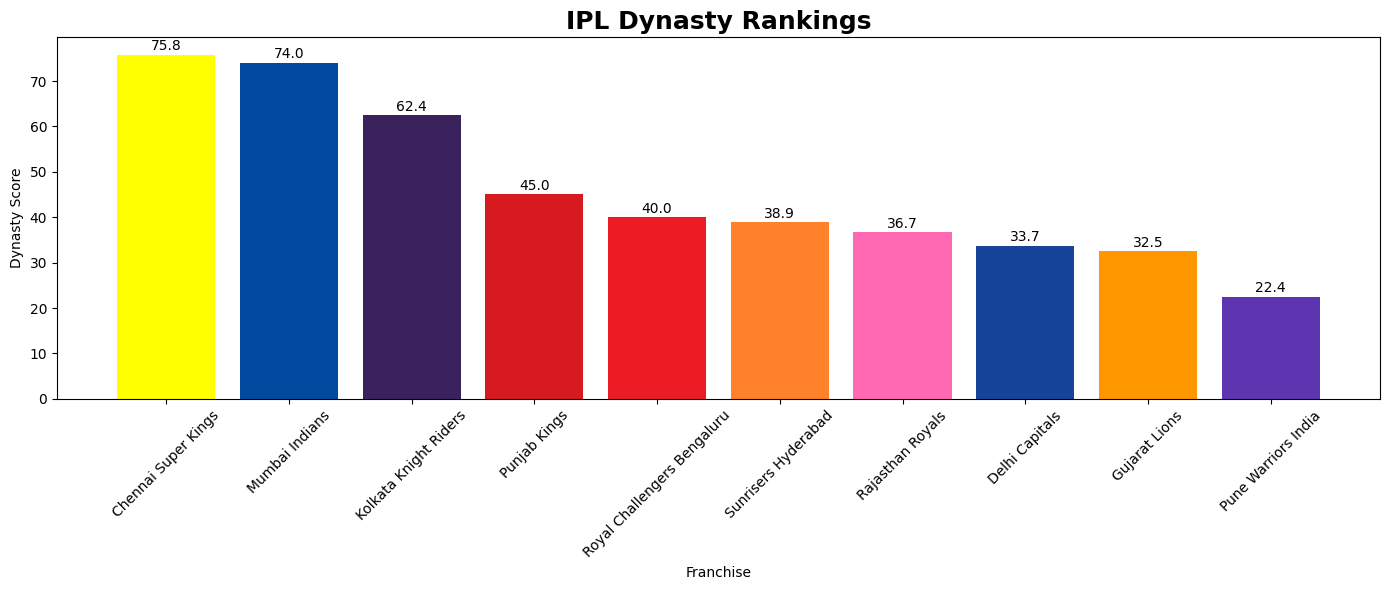

In [19]:
top10 = dynasty_rankings.head(10)

colors = [
    TEAM_COLORS.get(team, "#808080")
    for team in top10["team"]
]

plt.figure(figsize=(14,6))

bars = plt.bar(
    top10["team"],
    top10["dynasty_score"],
    color=colors
)

plt.title(
    "IPL Dynasty Rankings",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Franchise")
plt.ylabel("Dynasty Score")

plt.xticks(rotation=45)

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [20]:
dynasty_rankings["dynasty_tier"] = pd.cut(
    dynasty_rankings["dynasty_score"],
    bins=[0,40,60,80,100],
    labels=[
        "Developing",
        "Competitive",
        "Elite",
        "Dynasty"
    ]
)

dynasty_rankings.head()

,rank,team,strength_score,dna_score,pressure_score,venue_dominance_score,dynasty_score,titles,dynasty_tier
0,1,Chennai Super Kings,0.340840,0.874217,1.000000,0.752294,75.84,5.0,Elite
1,2,Mumbai Indians,0.243893,1.000000,0.909626,0.706905,74.04,5.0,Elite
2,3,Kolkata Knight Riders,0.245802,0.901519,0.846262,0.716562,62.42,3.0,Elite
3,4,Punjab Kings,0.352290,0.945551,0.290835,1.000000,45.02,0.0,Competitive
4,5,Royal Challengers Bengaluru,0.176718,0.952633,0.304788,0.952197,39.97,0.0,Developing


In [21]:
final_dynasty_rankings = dynasty_rankings[
    [
        "rank",
        "team",
        "dynasty_score",
        "dynasty_tier"
    ]
]

final_dynasty_rankings.head(15)

,rank,team,dynasty_score,dynasty_tier
0,1,Chennai Super Kings,75.84,Elite
1,2,Mumbai Indians,74.04,Elite
2,3,Kolkata Knight Riders,62.42,Elite
3,4,Punjab Kings,45.02,Competitive
4,5,Royal Challengers Bengaluru,39.97,Developing
5,6,Sunrisers Hyderabad,38.86,Developing
6,7,Rajasthan Royals,36.70,Developing
7,8,Delhi Capitals,33.73,Developing
8,9,Gujarat Lions,32.46,Developing
9,10,Pune Warriors India,22.45,Developing


In [14]:
final_dynasty_rankings.head(15)

,rank,team,dynasty_score,dynasty_tier
0,1,Chennai Super Kings,70.68,Elite
1,2,Mumbai Indians,68.35,Elite
2,3,Kolkata Knight Riders,63.97,Elite
3,4,Punjab Kings,57.97,Competitive
4,5,Royal Challengers Bengaluru,51.91,Competitive
5,6,Sunrisers Hyderabad,44.64,Competitive
6,7,Delhi Capitals,44.28,Competitive
7,8,Rajasthan Royals,42.34,Competitive
8,9,Gujarat Lions,39.93,Developing
9,10,Pune Warriors India,28.11,Developing


In [13]:
final_dynasty_rankings.to_csv(
    "ipl_dynasty_rankings.csv",
    index=False
)